In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process
import importlib
from tqdm.auto import tqdm
import multiprocessing as mp

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


# Load pre-computed human threshold data

In [2]:
path_to_human_results = Path('final_results_dir')

human_thresh_df = pd.read_pickle(path_to_human_results / 'summary_2024_human_threshold_results_avg_sex_cond.pdpkl')
human_thresh_df_per_sex = pd.read_pickle(path_to_human_results / 'summary_2024_human_threshold_results_split_by_sex_cond.pdpkl')

In [4]:
N = 33

In [5]:

human_thresh_df_summary = human_thresh_df.groupby(['elev_delta', 'azim_delta']).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_thresh_df_summary.columns = ['elev_delta', 'azim_delta', 'threshold', 'threshold_std']


human_thresh_df_summary_per_sex = human_thresh_df_per_sex.groupby(['elev_delta', 'azim_delta', 'sex_cond']).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_thresh_df_summary_per_sex.columns = ['elev_delta', 'azim_delta', 'sex_cond', 'threshold', 'threshold_std']


In [6]:
human_thresh_df_summary

,elev_delta,azim_delta,threshold,threshold_std
0,0,0,0.059140,0.486347
1,0,10,-2.814872,0.635813
2,0,60,-5.495252,0.640000
3,10,0,-1.474366,0.462032
4,60,0,-1.585866,0.504760


## Load model data and meta files

In [8]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [9]:
import pickle 

manifest_path = "binaural_test_manifests/human_array_exmpt_sim_v02_only_human_locs_w_noise_min_reverb_mit_room_v02.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [10]:
manifest_df  = pd.DataFrame(manifest.values())
# manifest_df

In [11]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [12]:

output_paths = list(Path(f"binaural_eval/simulate_2024_human_threshold_experiment_v02_30_dB_pink_noise_min_verb_mit46_1004").glob("*/*.pkl"))
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_threshold_experiment_v02_cue_noise").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')


word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

wanted_models = [
    # 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
                #  'word_task_v09_cue_loc_task',
                'word_task_v10_main_feature_gain_config',
                #  'word_task_v09_4MGB_ln_first_arch_1',
                # 'word_task_v09_4MGB_ln_first_arch_2',
                # 'word_task_v09_4MGB_ln_first_arch_4',
                # 'word_task_v09_4MGB_ln_first_arch_6',
                # 'word_task_v09_4MGB_ln_first_arch_7',
                # 'word_task_v09_4MGB_ln_first_arch_8',
                # 'word_task_v09_4MGB_ln_first_arch_9',
]

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not any([model in path.stem for model in wanted_models]):
        continue
    # if not 'v09' in str(path):
    #     continue
    # if 'modulated' in path.stem:
    #     continue 
    # if not 'mitb46' in path.stem:
    #     continue 
    # if 'white_noise' in path.as_posix():
    #     continue
    # if 'texture' in path.as_posix():
    #     continue

    res_dict = pickle.load(open(path, 'rb'))
    to_track = {key:val for key,val in res_dict.items() if key != 'textures'}

    df = pd.DataFrame.from_dict(to_track)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    ## Get SNR level from path
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    ## Get texture leve lfrom path 
    if "no_texture" in path.stem:
        texture_level = 'no_texture'
    
    elif 'texture' in path.stem: 
        texture_level = re.search('(-?\d+)dB_bg_texture',path.stem).group(0).split('dB')[0]
    elif 'pink_noise' in path.stem:
        texture_level = re.search('(-?\d+)dB_bg_pink_noise',path.stem).group(0).split('dB')[0]


    df['texture_level'] = texture_level
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    # if 'white_noise' in path.as_posix():
    #     df['distractor_type'] = 'white_noise'
    # elif 'texture' in path.as_posix():
    #     df['distractor_type'] = 'texture'
    # else:
    # df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [13]:
results.loc[results.room_type.str.contains('eval'), 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type.str.contains('mitb46'), 'room_str'] = 'Normal speaker array'
results.loc[results.room_type.str.contains('mitb46'), 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [14]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set',  'texture_level',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [15]:
grouped_model_results['distractor_elev_delta'] = (grouped_model_results['target_elev'] - grouped_model_results['distractor_elev']).abs()

In [16]:
grouped_model_results.texture_level.unique()

array(['30'], dtype=object)

In [19]:
grouped_model_results['azim_delta'] = (grouped_model_results['distractor_azim'] - grouped_model_results['target_azim']).abs()
grouped_model_results['elev_delta'] = (grouped_model_results['distractor_elev'] - grouped_model_results['target_elev']).abs()

In [20]:
## Fit model thresholds per texture level 
np.random.seed(0)
n_boots = 1_000  ## use 10_000 for final analysis


model_thresholds = []

for (model, texture_level, dist_azim, dist_elev), data in grouped_model_results.groupby(['model', 'texture_level', 'azim_delta', 'elev_delta']):
    for i in tqdm(range(n_boots)):
        boot_data = data.sample(frac=1, replace=True)
        results_for_thresh = boot_data.groupby('snr').agg({'accuracy_mean':'mean'}).reset_index()
        try:
            thresh, poly = util_analysis.estimate_threshold_poly(results_for_thresh.snr.values, results_for_thresh.accuracy_mean.values, degree=2)
        except:
            thresh = np.nan
        model_thresholds.append({
                        'model':model, 'texture_level':texture_level, 'azim_delta':dist_azim, 'elev_delta':dist_elev,
                        'threshold':thresh})


model_thresh_df = pd.DataFrame(model_thresholds)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [21]:
## Fit model thresholds per texture level 
np.random.seed(0)
n_boots = 1_000  ## use 10_000 for final analysis

model_thresholds = []

for (model, texture_level, dist_azim, dist_elev, sex_cond), data in grouped_model_results.groupby(['model', 'texture_level', 'azim_delta', 'elev_delta', 'sex_cond']):
    for i in tqdm(range(n_boots)):
        boot_data = data.sample(frac=1, replace=True)
        results_for_thresh = boot_data.groupby('snr').agg({'accuracy_mean':'mean'}).reset_index()
        try:
            thresh, poly = util_analysis.estimate_threshold_poly(results_for_thresh.snr.values, results_for_thresh.accuracy_mean.values, degree=2)
        except:
            thresh = 6 # set to max snr tested
        model_thresholds.append({
                        'model':model, 'texture_level':texture_level, 'azim_delta':dist_azim, 'elev_delta':dist_elev, "sex_cond":sex_cond,
                        'threshold':thresh})

model_thresh_df_sex_cond = pd.DataFrame(model_thresholds)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


In [22]:

model_thresh_df_summary = model_thresh_df.groupby(['model', 'elev_delta', 'azim_delta']).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
model_thresh_df_summary.columns = ['model', 'elev_delta', 'azim_delta', 'threshold', 'threshold_std']


model_thresh_df_summary_per_sex = model_thresh_df_sex_cond.groupby(['model', 'elev_delta', 'azim_delta', 'sex_cond']).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
model_thresh_df_summary_per_sex.columns = ['model', 'elev_delta', 'azim_delta', 'sex_cond', 'threshold', 'threshold_std']


## Make figures for talk 

In [23]:
outfig_dest = Path('ARO_2025/')
outfig_dest.mkdir(parents=True, exist_ok=True)

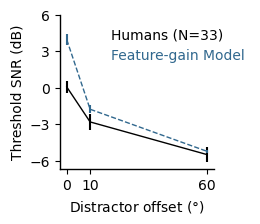

In [24]:
aspect = 2
fontsize=10
ratio = 1
tick_fontsize = 10
line_thickness = 1

fig, ax = plt.subplots(1,  figsize=((aspect)  , aspect ))
err_band_alpha = 0.4

palette = sns.color_palette("viridis", n_colors=2)
cmap = {}
cmap[f"Humans (N={N})"] = 'k'
cmap['Feature-gain Model'] = palette[0]

for ix in range(2):
    if ix == 0:
        azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
    elif ix == 1: 
        azim_data = model_thresh_df_summary[(model_thresh_df_summary.elev_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
    azim_to_plot = azim_data
    # compute spatial release 
    # azim_to_plot['spatial_release'] = azim_to_plot.threshold - azim_to_plot.loc[azim_to_plot.azim_delta == 0, 'threshold'].item()
    label = f"Humans (N={N})" if ix == 0 else "Feature-gain Model"
    ax.errorbar(data=azim_to_plot, x=azim_to_plot.azim_delta, y='threshold', yerr='threshold_std', label=label, color=cmap[label] )


    ax.set_xlabel('Distractor offset ($\degree$)', fontsize=fontsize)
    # if ix == 0:
    ax.set_ylabel('Threshold SNR (dB)', fontsize=fontsize)
    # else:
    #     ax.set_ylabel('')
    ax.set_xticks([0, 10, 60])
    ax.set_yticks(np.arange(-6, 7, 3))
    # if ix == 0:
    #     ax.set_title(f"Humans (N={N})", fontsize=fontsize )
    # elif ix == 1:
    #     ax.set_title("Feature-gain Model", fontsize=fontsize )

    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for jx, line in enumerate(ax.get_lines()):
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        # line.set_markersize(6)
        # line.set_markeredgewidth(.4)
        if jx == 0:
            line.set_linestyle('-')
        elif jx == 1:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')
    # if ix == 0:
    #     ax.legend().remove()
    # else:

legend = ax.legend(
    # loc='upper right',
            frameon=False,
            bbox_to_anchor=(0.25, 1),
            handlelength=0, handleheight=0, handletextpad=0,
            # markerscale=0, 
            #numpoints=1
            
            fontsize=fontsize)

for text in legend.get_texts():
    text.set_color(cmap[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)

plt.subplots_adjust(wspace=0.01)
sns.despine()
# plt.savefig(outfig_dest/'human_model_thresholds_azimuth_only_same_panel.pdf', transparent=True, bbox_inches='tight')
# 

## Elevation masking release

/tmp/ipykernel_2307273/932179948.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elev_to_plot['spatial_release'] = elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()
/tmp/ipykernel_2307273/932179948.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elev_to_plot['spatial_release'] = elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()


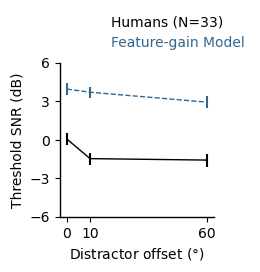

In [25]:
aspect = 2
fontsize=10
ratio = 1
tick_fontsize = 10
line_thickness = 1

fig, ax = plt.subplots(1,  figsize=((aspect)  , aspect ))
err_band_alpha = 0.4

palette = sns.color_palette("viridis", n_colors=2)
cmap = {}
cmap[f"Humans (N={N})"] = 'k'
cmap['Feature-gain Model'] = palette[0]

for ix in range(2):
    if ix == 0:
        elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
    elif ix == 1: 
        elev_data = model_thresh_df_summary[(model_thresh_df_summary.azim_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
    elev_to_plot = elev_data
    # compute spatial release 
    elev_to_plot['spatial_release'] = elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()
    label = f"Humans (N={N})" if ix == 0 else "Feature-gain Model"
    ax.errorbar(data=elev_to_plot, x=elev_to_plot.elev_delta, y='threshold', yerr='threshold_std', label=label, color=cmap[label] )


    ax.set_xlabel('Distractor offset ($\degree$)', fontsize=fontsize)
    # if ix == 0:
    ax.set_ylabel('Threshold SNR (dB)', fontsize=fontsize)
    # else:
    #     ax.set_ylabel('')
    ax.set_xticks([0, 10, 60])
    ax.set_yticks(np.arange(-6, 7, 3))
    # if ix == 0:
    #     ax.set_title(f"Humans (N={N})", fontsize=fontsize )
    # elif ix == 1:
    #     ax.set_title("Feature-gain Model", fontsize=fontsize )

    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for jx, line in enumerate(ax.get_lines()):
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        # line.set_markersize(6)
        # line.set_markeredgewidth(.4)
        if jx == 0:
            line.set_linestyle('-')
        elif jx == 1:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')
    # if ix == 0:
    #     ax.legend().remove()
    # else:

legend = ax.legend(
    # loc='upper right',
            frameon=False,
            bbox_to_anchor=(0.25, 1),
            handlelength=0, handleheight=0, handletextpad=0,
            # markerscale=0, 
            #numpoints=1
            
            fontsize=fontsize)

for text in legend.get_texts():
    text.set_color(cmap[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)

plt.subplots_adjust(wspace=0.01)
sns.despine()
plt.savefig(outfig_dest/'human_model_spatial_release_elevation_only_same_panel.pdf', transparent=True, bbox_inches='tight')
# 

## Plot relative improvement summary 

In [74]:
human_thresh_df

,azim_delta,elev_delta,threshold,n_participants
0,0,0,-0.336336,33
1,0,0,-0.126126,33
2,0,0,0.114114,33
3,0,0,0.249249,33
4,0,0,0.069069,33
...,...,...,...,...
49995,60,0,-5.156156,33
49996,60,0,-5.561562,33
49997,60,0,-5.471471,33
49998,60,0,-5.471471,33


In [81]:
elev_data = human_thresh_df[human_thresh_df.azim_delta == 0].copy()
elev_data['db_improvement'] =(elev_data.threshold - elev_data.loc[elev_data.elev_delta == 0, 'threshold'].mean()).abs()
elev_data.groupby('elev_delta').agg({'db_improvement':['mean', 'std']})

db_improvement          
                     mean       std
elev_delta                         
0                0.389636  0.291036
10               1.533688  0.461427
60               1.645129  0.504359

/tmp/ipykernel_2307273/4038365204.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elev_to_plot['db_improvement'] = (elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()).abs()
/tmp/ipykernel_2307273/4038365204.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  azim_to_plot['db_improvement'] = (azim_to_plot.threshold - azim_to_plot.loc[azim_to_plot.azim_delta == 0, 'threshold'].item()).abs()
/tmp/ipykernel_2307273/4038365204.py:29: SettingWithCopyWarning: 
A valu

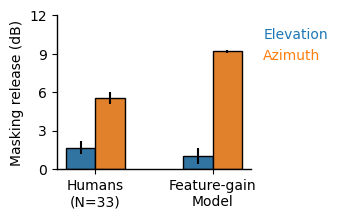

In [94]:
aspect = 2
fontsize=10
ratio = 1
tick_fontsize = 10
line_thickness = 1
# 
fig, ax = plt.subplots(1, figsize=(2.5  , 2 ))
err_band_alpha = 0.4

palette = sns.color_palette('tab10', n_colors=2)
cmap = {}
cmap['Elevation'] = palette[0]
cmap['Azimuth'] = palette[1]

improvement_results = []

for ix in range(2):
    if ix == 0:
        elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
        azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
        group = f"Humans\n(N={N})"
    elif ix == 1: 
        elev_data = model_thresh_df_summary[(model_thresh_df_summary.azim_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
        azim_data = model_thresh_df_summary[(model_thresh_df_summary.elev_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
        group = "Feature-gain\nModel"
    elev_to_plot = elev_data
    azim_to_plot = azim_data
    
    elev_to_plot['db_improvement'] = (elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()).abs()
    azim_to_plot['db_improvement'] = (azim_to_plot.threshold - azim_to_plot.loc[azim_to_plot.azim_delta == 0, 'threshold'].item()).abs()

    # improvement at 60 deg
    improvement_results.append({"group":group,
                                "plane":"Elevation",
                                "improvement":elev_to_plot.loc[elev_to_plot.elev_delta == 60, 'db_improvement'].item(),
                                "error": elev_to_plot.loc[elev_to_plot.elev_delta == 60, 'threshold_std'].item()})
    improvement_results.append({"group":group,
                                "plane":"Azimuth",
                                "improvement":azim_to_plot.loc[azim_to_plot.azim_delta == 60, 'db_improvement'].item(),
                                "error": azim_to_plot.loc[azim_to_plot.azim_delta == 60, 'threshold_std'].item()})

improvement_df = pd.DataFrame(improvement_results)       

sns.barplot(data=improvement_df,
            x='group',
            y='improvement',
            width=0.5,
            hue='plane', ax=ax, palette=cmap)

# add errorbars 
for i, bar in enumerate(ax.patches):
    # bar.set_alpha(0.5)
    bar.set_edgecolor('k')
    bar.set_linewidth(1)
    # if i % 2 == 0:
    #     bar.set_hatch('/')
    # else:
    #     # bar.set_hatch('\\')
    error = improvement_df.loc[i, 'error']
    ax.errorbar(x=bar.get_x() + bar.get_width() / 2, y=bar.get_height(), yerr=error, fmt=' ', color='k', capsize=0, capthick=1)


# ax.legend(loc='lower left', bbox_to_anchor=(1, 0.25), fontsize=fontsize, markerscale=0)
# ax.get_legend().get_frame().set_linewidth(0.0)

ax.set_xlabel('', fontsize=fontsize)


ax.set_ylabel('Masking release (dB)', fontsize=fontsize)

# ax.set_xticks([0, 10, 60])
ax.set_yticks(np.arange(0, 13, 3))

# xleft, xright = ax.get_xlim()
# ybottom, ytop = ax.get_ylim()
# ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
for line in ax.get_lines():
#     line.set_markerfacecolor(line.get_color())
#     line.set_markeredgecolor('w')
    line.set_linewidth(1)
    line.set_markersize(6)
    line.set_markeredgewidth(.4)
    if ix == 1:
        line.set_linestyle('--')

# set line thickness for pannel
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(line_thickness)
    ax.spines[axis].set_color('k')

legend = ax.legend(
    # loc='upper right',
            frameon=False,
            bbox_to_anchor=(1, 1),
            handlelength=0, handleheight=0, handletextpad=0,
            markerscale=0, 
            #numpoints=1
            
            fontsize=fontsize)

for text in legend.get_texts():
    text.set_color(cmap[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)

# plt.subplots_adjust(wspace=0.01)
sns.despine()
# plt.savefig(outfig_dest/'spatial_release_sumary_plot.pdf', transparent=True, bbox_inches='tight')



In [53]:
improvement_df

,group,plane,improvement
0,Humans (N=33),Elevation,1.645006
1,Humans (N=33),Azimuth,5.554392
2,Feature-gain Model,Elevation,1.016120
3,Feature-gain Model,Azimuth,9.171283


### Plot azim thresholds

/tmp/ipykernel_2286108/3202060994.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  azim_to_plot['spatial_release'] = azim_to_plot.threshold - azim_to_plot.loc[azim_to_plot.azim_delta == 0, 'threshold'].item()
/tmp/ipykernel_2286108/3202060994.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  azim_to_plot['spatial_release'] = azim_to_plot.threshold - azim_to_plot.loc[azim_to_plot.azim_delta == 0, 'threshold'].item()


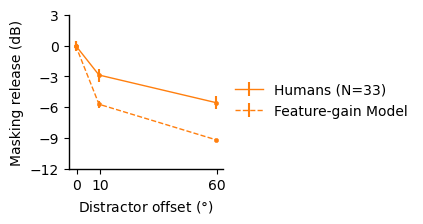

In [84]:
aspect = 2
fontsize=10
ratio = 1
tick_fontsize = 10
line_thickness = 1

fig, ax = plt.subplots(1,  figsize=((aspect)  , aspect ))
err_band_alpha = 0.4

palette = sns.color_palette('tab10', n_colors=2)
cmap = {}
cmap['Elevation'] = palette[0]
cmap['Azimuth'] = palette[1]

for ix in range(2):
    if ix == 0:
        azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
    elif ix == 1: 
        azim_data = model_thresh_df_summary[(model_thresh_df_summary.elev_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
    azim_to_plot = azim_data
    # compute spatial release 
    azim_to_plot['spatial_release'] = azim_to_plot.threshold - azim_to_plot.loc[azim_to_plot.azim_delta == 0, 'threshold'].item()
    label = f"Humans (N={N})" if ix == 0 else "Feature-gain Model"
    ax.errorbar(data=azim_to_plot, x=azim_to_plot.azim_delta - 0.5, y='spatial_release', yerr='threshold_std', fmt='.-', label=label, color=cmap['Azimuth'] )


    ax.set_xlabel('Distractor offset ($\degree$)', fontsize=fontsize)
    # if ix == 0:
    ax.set_ylabel('Masking release (dB)', fontsize=fontsize)
    # else:
    #     ax.set_ylabel('')
    ax.set_xticks([0, 10, 60])
    ax.set_yticks(np.arange(-12, 4, 3))
    # if ix == 0:
    #     ax.set_title(f"Humans (N={N})", fontsize=fontsize )
    # elif ix == 1:
    #     ax.set_title("Feature-gain Model", fontsize=fontsize )

    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for jx, line in enumerate(ax.get_lines()):
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if jx == 0:
            line.set_linestyle('-')
        elif jx == 1:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')
    # if ix == 0:
    #     ax.legend().remove()
    # else:

    ax.legend(loc='lower left', bbox_to_anchor=(1, 0.25), fontsize=fontsize, markerscale=0, numpoints=1)
    ax.get_legend().get_frame().set_linewidth(0.0)

plt.subplots_adjust(wspace=0.01)
sns.despine()
# plt.savefig(outfig_dest/'human_model_thresholds_azimuth_only.pdf', transparent=True, bbox_inches='tight')



### Plot elevation thresholds

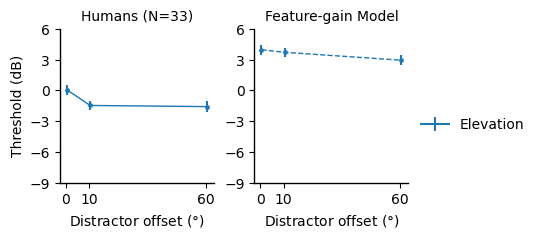

In [62]:
aspect = 2
fontsize=10
ratio = 1
tick_fontsize = 10
line_thickness = 1

fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))
err_band_alpha = 0.4

palette = sns.color_palette('tab10', n_colors=2)
cmap = {}
cmap['Elevation'] = palette[0]
cmap['Azimuth'] = palette[1]

for ix, ax in enumerate(axs):
    if ix == 0:
        elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
        azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
    elif ix == 1: 
        elev_data = model_thresh_df_summary[(model_thresh_df_summary.azim_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
        azim_data = model_thresh_df_summary[(model_thresh_df_summary.elev_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
    elev_to_plot = elev_data
    azim_to_plot = azim_data
  
    ax.errorbar(data=elev_to_plot, x=elev_to_plot.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='.-', label='Elevation', color=cmap['Elevation'])
    # ax.errorbar(data=azim_to_plot, x=azim_to_plot.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='.-', label='Azimuth', color=cmap['Azimuth'] )

    if ix == 0:
        ax.legend().remove()
    else:

        ax.legend(loc='lower left', bbox_to_anchor=(1, 0.25), fontsize=fontsize, markerscale=0)
        ax.get_legend().get_frame().set_linewidth(0.0)

    ax.set_xlabel('Distractor offset ($\degree$)', fontsize=fontsize)
    if ix == 0:
        ax.set_ylabel('Threshold (dB)', fontsize=fontsize)
    else:
        ax.set_ylabel('')
    ax.set_xticks([0, 10, 60])
    ax.set_yticks(np.arange(-9, 7, 3))
    if ix == 0:
        ax.set_title(f"Humans (N={N})", fontsize=fontsize )
    elif ix == 1:
        ax.set_title("Feature-gain Model", fontsize=fontsize )

    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if ix == 1:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

plt.subplots_adjust(wspace=0.01)
sns.despine()
# plt.savefig(outfig_dest/'human_model_thresholds_elevation_only.pdf', transparent=True, bbox_inches='tight')



/tmp/ipykernel_2286108/271525985.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elev_to_plot['spatial_release'] = elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()
/tmp/ipykernel_2286108/271525985.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elev_to_plot['spatial_release'] = elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()


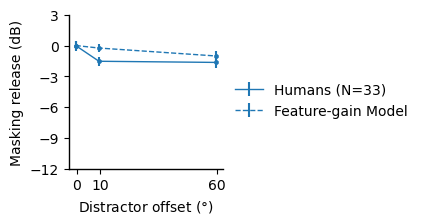

In [88]:
aspect = 2
fontsize=10
ratio = 1
tick_fontsize = 10
line_thickness = 1

fig, ax = plt.subplots(1,  figsize=((aspect)  , aspect ))
err_band_alpha = 0.4

palette = sns.color_palette('tab10', n_colors=2)
cmap = {}
cmap['Elevation'] = palette[0]
cmap['Azimuth'] = palette[1]

for ix in range(2):
    if ix == 0:
        elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
    elif ix == 1: 
        elev_data = model_thresh_df_summary[(model_thresh_df_summary.azim_delta == 0) & (model_thresh_df_summary.model.str.contains('v10'))]
    elev_to_plot = elev_data
  
    # compute spatial release 
    elev_to_plot['spatial_release'] = elev_to_plot.threshold - elev_to_plot.loc[elev_to_plot.elev_delta == 0, 'threshold'].item()
    label = f"Humans (N={N})" if ix == 0 else "Feature-gain Model"
    ax.errorbar(data=elev_to_plot, x=elev_to_plot.elev_delta - 0.5, y='spatial_release', yerr='threshold_std', fmt='.-', label=label, color=cmap['Elevation'] )


    ax.set_xlabel('Distractor offset ($\degree$)', fontsize=fontsize)
    # if ix == 0:
    ax.set_ylabel('Masking release (dB)', fontsize=fontsize)
    # else:
    #     ax.set_ylabel('')
    ax.set_xticks([0, 10, 60])
    ax.set_yticks(np.arange(-12, 4, 3))
    # if ix == 0:
    #     ax.set_title(f"Humans (N={N})", fontsize=fontsize )
    # elif ix == 1:
    #     ax.set_title("Feature-gain Model", fontsize=fontsize )

    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for jx, line in enumerate(ax.get_lines()):
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if jx == 0:
            line.set_linestyle('-')
        elif jx == 1:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')
    # if ix == 0:
    #     ax.legend().remove()
    # else:

    ax.legend(loc='lower left', bbox_to_anchor=(1, 0.25), fontsize=fontsize, markerscale=0, numpoints=1)
    ax.get_legend().get_frame().set_linewidth(0.0)

plt.subplots_adjust(wspace=0.01)
sns.despine()
# plt.savefig(outfig_dest/'human_model_thresholds_azimuth_only.pdf', transparent=True, bbox_inches='tight')

